In [1]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 kB 2.0 MB/s eta 0:00:00a 0:00:01


In [2]:
!pip install -U ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 2.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.4/214.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 45.1 MB/s eta 0:00:0000:01
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.9
    Uninstalling widgetsnbextension-3.6.9:
      Successfully uninstalled widgetsnbextension-3.6.9
  Attempting uninstall: jupyterlab-widgets
    Found existing installation: jupyterlab_widgets 3.0.11
    Uninstalling jupyterlab_widgets-3.0.11:
      Successfully uninstalled jupyterlab_widgets-3.0.11
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
big

In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.8/883.8 kB 13.7 MB/s eta 0:00:00a 0:00:01


In [11]:
!pip install opencv-python

In [4]:
import wandb

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_1 = user_secrets.get_secret("roboflow_api_key")
secret_value_0 = user_secrets.get_secret("wandb_api_key")

In [6]:
from roboflow import Roboflow

rf = Roboflow(api_key=secret_value_1)

project = rf.workspace("miniproject-dfm83").project("helmetdetectiondataset")

version = project.version(7)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to HelmetDetectionDataset-7 in yolov8:: 100%|██████████| 2174/2174 [00:00<00:00, 7391.46it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [8]:
wandb.login(key=secret_value_0)

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

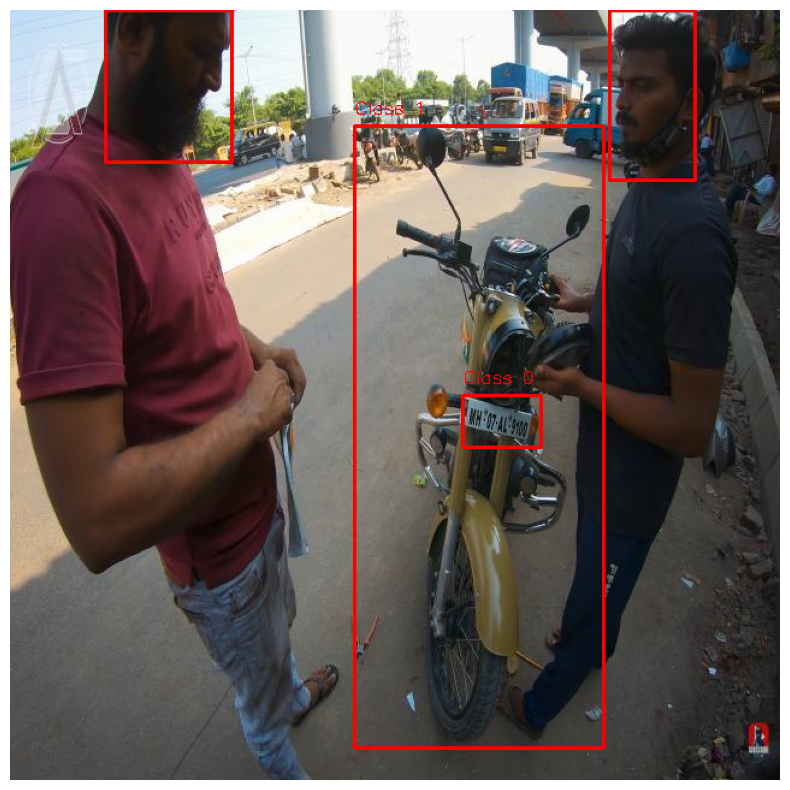

/kaggle/working/HelmetDetectionDataset-7/train/images/Screenshot-175-_png_jpg.rf.0e7e401bd90595a6886dfbeae457c9b4.jpg
/kaggle/working/HelmetDetectionDataset-7/train/labels/Screenshot-175-_png_jpg.rf.0e7e401bd90595a6886dfbeae457c9b4.txt


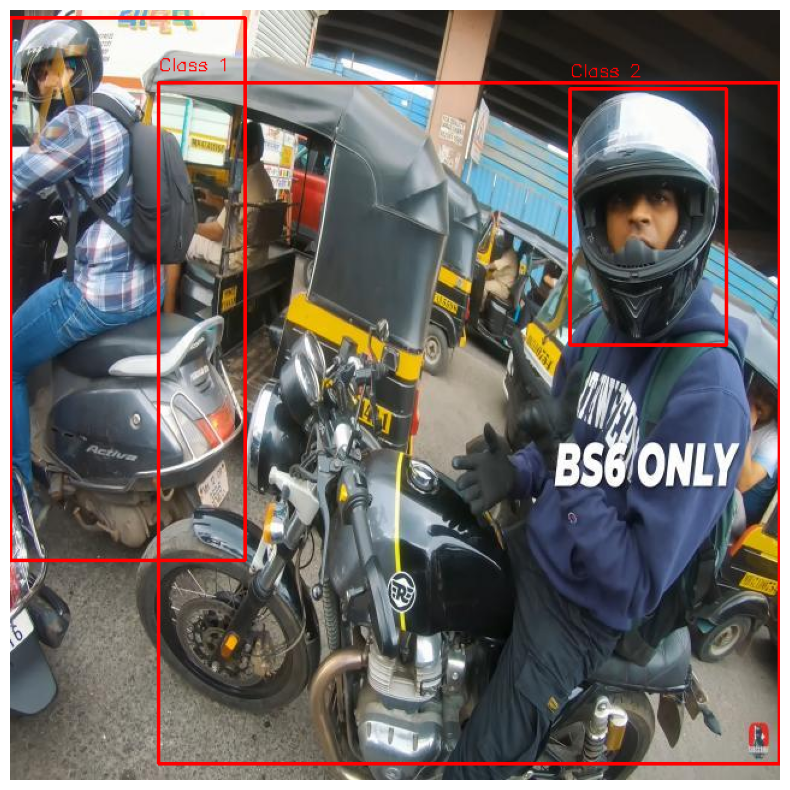

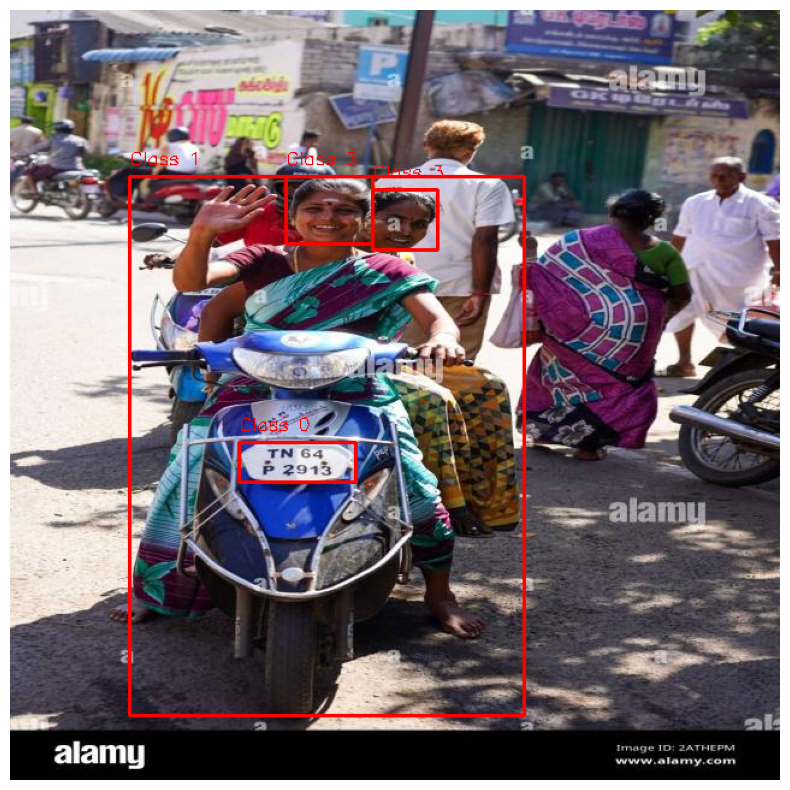

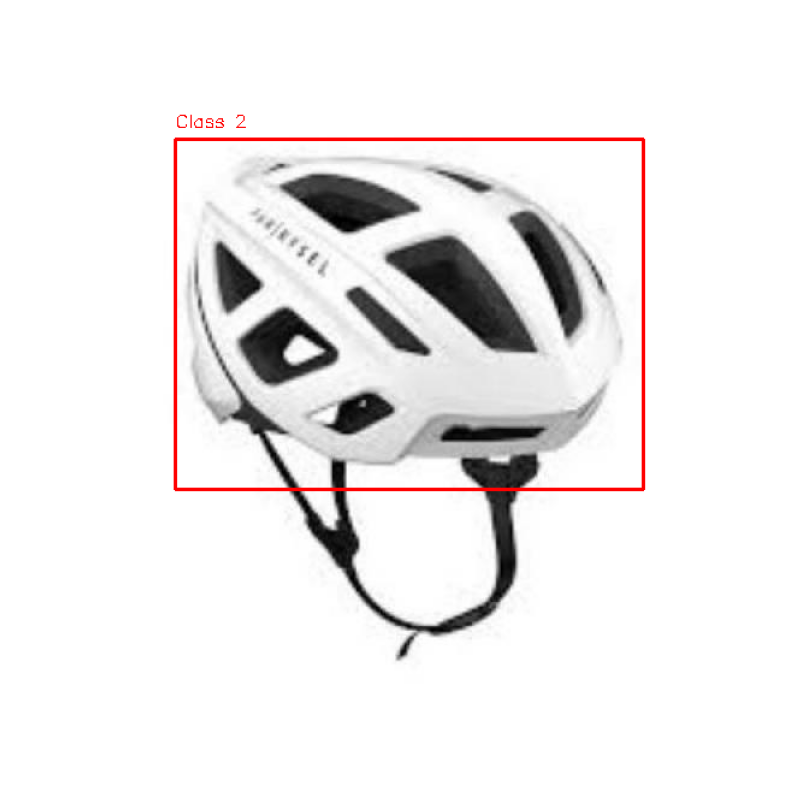

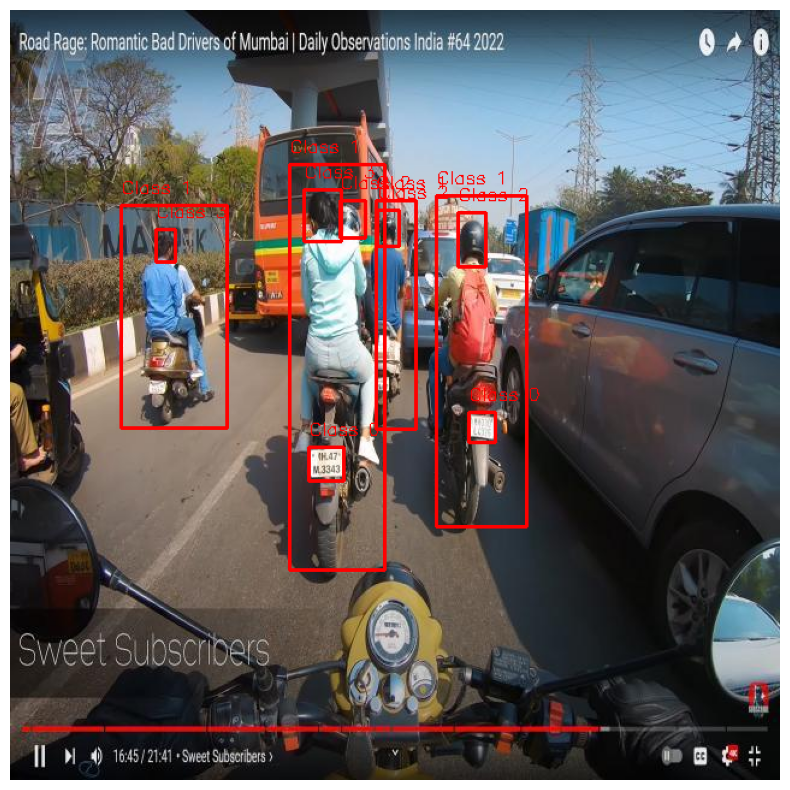

In [18]:
# Visualize dataset
import cv2
import matplotlib.pyplot as plt
import os

# Path to your images and annotations
image_dir = '/kaggle/working/HelmetDetectionDataset-7/train/images'
label_dir = '/kaggle/working/HelmetDetectionDataset-7/train/labels'

# Get a list of image files
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg')]

# Visualize a few images with bounding boxes
for image_file in image_files[:5]:  # Display only the first 5 images for brevity
    # Read image
    image_path = os.path.join(image_dir, image_file)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    error = []
    
    # Read corresponding annotation file
    annotation_path = os.path.join(label_dir, image_file.replace('.jpg', '.txt'))
    if os.path.exists(annotation_path):
        with open(annotation_path, 'r') as file:
            for line in file.readlines():
                parts = line.strip().split()
                if len(parts) <= 5:
                    class_id, x_center, y_center, width, height = map(float, line.strip().split())
                    
                    # Convert normalized coordinates to pixel coordinates
                    img_height, img_width = img.shape[:2]
                    x_center *= img_width
                    y_center *= img_height
                    width *= img_width
                    height *= img_height
                    
                    # Calculate top-left corner
                    top_left_x = int(x_center - width / 2)
                    top_left_y = int(y_center - height / 2)
                    bottom_right_x = int(x_center + width / 2)
                    bottom_right_y = int(y_center + height / 2)
                    
                    # Draw bounding box
                    cv2.rectangle(img, (top_left_x, top_left_y), (bottom_right_x, bottom_right_y), (255, 0, 0), 2)
                    cv2.putText(img, f'Class {int(class_id)}', (top_left_x, top_left_y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
                else:
                    print(image_path)
                    print(annotation_path)
    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    
    plt.show()

In [19]:
from ultralytics import YOLO

# Load a YOLO model
model = YOLO("yolo11n.pt")

# Train and Fine-Tune the Model
model.train(data="/kaggle/working/HelmetDetectionDataset-7/data.yaml", epochs=300, project="helme-detector", name="yolo11n")

# Finish the W&B run
wandb.finish()

100%|██████████| 5.35M/5.35M [00:00<00:00, 15.1MB/s]


Ultralytics 8.3.29 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/working/HelmetDetectionDataset-7/data.yaml, epochs=300, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=helme-detector, name=yolo11n, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, s

100%|██████████| 755k/755k [00:00<00:00, 3.14MB/s]


Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /kaggle/working/HelmetDetectionDataset-7/train/labels... 785 images, 0 backgrounds, 0 corrupt: 100%|██████████| 785/785 [00:00<00:00, 1130.16it/s]


...

    294/300      2.63G     0.5964     0.3983     0.9488          4        640: 100%|██████████| 50/50 [00:10<00:00,  4.76it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:01<00:00,  5.90it/s]

                   all        212        643      0.658       0.65      0.684      0.479
EarlyStopping: Training stopped early as no improvement observed in last 100 epochs. Best results observed at epoch 194, best model saved as best.pt.
To update EarlyStopping(patience=100) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



294 epochs completed in 1.040 hours.
Optimizer stripped from helme-detector/yolo11n/weights/last.pt, 5.5MB
Optimizer stripped from helme-detector/yolo11n/weights/best.pt, 5.5MB

Validating helme-detector/yolo11n/weights/best.pt...
Ultralytics 8.3.29 🚀 Python-3.10.14 torch-2.4.0 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 7/7 [00:02<00:00,  2.78it/s]


                   all        212        643      0.731      0.618      0.687      0.494
          number plate        120        150      0.854      0.741      0.825      0.549
                 rider         58         72      0.551      0.847      0.825      0.723
           with helmet        148        291      0.838      0.505      0.632      0.402
        without helmet         68        130      0.681      0.378      0.466      0.302
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to helme-detector/yolo11n


In [23]:
import os
model = YOLO("/kaggle/working/helme-detector/yolo11n/weights/best.pt")

# Define class IDs for motorbike and helmet
MOTORBIKE_CLASS_ID = 1  
HELMET_CLASS_ID = 2     
NO_HELMET_CLASS_ID = 3

results = model.predict(source='/kaggle/input/motorbike-helmet-dataset/input/videos/input2.mp4', stream=True, save=True)

# Create a directory to save images
output_dir = '/kaggle/working/inference_results/no_helmet_images'
os.makedirs(output_dir, exist_ok=True)

# Process all results and save images
frame_count = 0  # To keep track of frame numbers for unique image filenames
for r in results:
    frame = r.orig_img
    contains_motorbike_without_helmet = False

    # Check each detected box
    for box in r.boxes:
        class_id = int(box.cls[0])  # Get the class ID of the detected object

        if class_id == MOTORBIKE_CLASS_ID:
            # Check if there is no helmet in the same frame
            if not any(int(b.cls[0]) == HELMET_CLASS_ID for b in r.boxes):
                contains_motorbike_without_helmet = True
                break  # Stop checking once confirmed

    # Save only frames with motorbikes without helmets as images
    if contains_motorbike_without_helmet:
        frame_filename = os.path.join(output_dir, f'frame_{frame_count:04d}.jpg')
        cv2.imwrite(frame_filename, frame)
        frame_count += 1

print(f"Images with motorbikes without helmets saved in {output_dir}")


video 1/1 (frame 1/1837) /kaggle/input/motorbike-helmet-dataset/input/videos/input2.mp4: 384x640 (no detections), 12.1ms
video 1/1 (frame 2/1837) /kaggle/input/motorbike-helmet-dataset/input/videos/input2.mp4: 384x640 (no detections), 10.7ms
video 1/1 (frame 3/1837) /kaggle/input/motorbike-helmet-dataset/input/videos/input2.mp4: 384x640 (no detections), 9.8ms
video 1/1 (frame 4/1837) /kaggle/input/motorbike-helmet-dataset/input/videos/input2.mp4: 384x640 (no detections), 9.6ms
video 1/1 (frame 5/1837) /kaggle/input/motorbike-helmet-dataset/input/videos/input2.mp4: 384x640 (no detections), 9.7ms
video 1/1 (frame 6/1837) /kaggle/input/motorbike-helmet-dataset/input/videos/input2.mp4: 384x640 (no detections), 9.5ms
video 1/1 (frame 7/1837) /kaggle/input/motorbike-helmet-dataset/input/videos/input2.mp4: 384x640 1 rider, 9.7ms
video 1/1 (frame 8/1837) /kaggle/input/motorbike-helmet-dataset/input/videos/input2.mp4: 384x640 (no detections), 10.0ms
video 1/1 (frame 9/1837) /kaggle/input/motor

In [9]:
import cv2
def convert_avi_to_mp4(input_path, output_path):
    """Convert an AVI video file to MP4 format using OpenCV."""
    cap = cv2.VideoCapture(input_path)
    
    # Get the video's properties (frame width, height, and FPS)
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Define the codec and create a VideoWriter object for MP4 output
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for MP4 format
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    # Read and write each frame to the new video file
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        out.write(frame)
        
    # Release resources
    cap.release()
    out.release()
    print(f"Video saved as {output_path}")